  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8595505617977528

Confusion Matrix:
[[442  13]
 [ 62  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       455
           1       0.57      0.22      0.31        79

    accuracy                           0.86       534
   macro avg       0.72      0.59      0.62       534
weighted avg       0.83      0.86      0.83       534



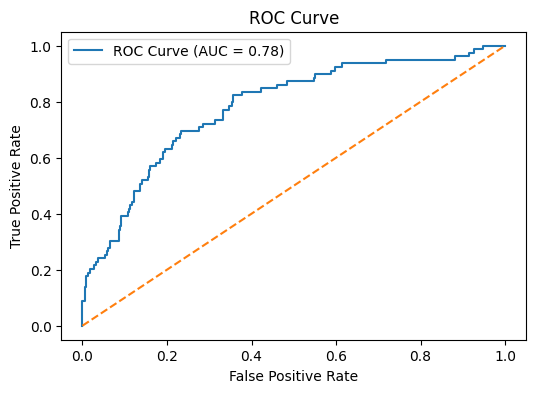

                   Feature  Coefficient
0                    State    -0.000100
1           Account length     0.000838
2       International plan     2.252337
3          Voice mail plan    -1.669194
4    Number vmail messages     0.022718
5        Total day minutes     0.018384
6          Total day calls     0.002331
7         Total day charge    -0.028439
8        Total eve minutes     0.007093
9          Total eve calls    -0.000953
10        Total eve charge    -0.022222
11     Total night minutes     0.003223
12       Total night calls    -0.003335
13      Total night charge    -0.017116
14      Total intl minutes     0.081069
15        Total intl calls    -0.116510
16       Total intl charge     0.053692
17  Customer service calls     0.497173


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split

# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv('/content/churn-bigml-80.csv')

# Display first 5 rows
print(df.head())

# Dataset info
print(df.info())

# ==============================
# DATA PREPROCESSING
# ==============================

# Remove unnecessary column
df.drop('Area code', axis=1, inplace=True)

# Convert categorical columns into numerical values
encoder = LabelEncoder()

df['State'] = encoder.fit_transform(df['State'])
df['International plan'] = encoder.fit_transform(df['International plan'])
df['Voice mail plan'] = encoder.fit_transform(df['Voice mail plan'])
df['Churn'] = encoder.fit_transform(df['Churn'])

# ==============================
# DEFINE FEATURES & TARGET
# ==============================

X = df.drop('Churn', axis=1)
y = df['Churn']

# ==============================
# SPLIT DATA
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# TRAIN MODEL
# ==============================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# ==============================
# PREDICTIONS
# ==============================

y_pred = model.predict(X_test)

# ==============================
# EVALUATION
# ==============================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==============================
# ROC CURVE
# ==============================

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ==============================
# MODEL COEFFICIENTS
# ==============================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

# New Section